# Bibliotecas

In [38]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression

# Coleta de Dados

In [39]:
# Carregando base de treino e de teste
df_train = pd.read_csv('train.csv')
print(f"df_train: Linhas [{df_train.shape[0]}] | Colunas [{df_train.shape[0]}]")
df_test = pd.read_csv('test.csv')
print(f"df_test: Linhas [{df_test.shape[0]}] | Colunas [{df_test.shape[0]}]")
# Criando um novo DataFrame com a união dos dois anteriores e sem a variáavel resposta para fazer limpeza dos dados e a engenharia de atributos
df_concat = pd.concat([df_train.drop('Survived',axis=1),df_test], axis=0).reset_index(drop=True)
print(f"df_concat: Linhas [{df_concat.shape[0]}] | Colunas [{df_concat.shape[0]}]")

df_train: Linhas [891] | Colunas [891]
df_test: Linhas [418] | Colunas [418]
df_concat: Linhas [1309] | Colunas [1309]


In [40]:
# Visualização das primeiras linhas
df_concat.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [41]:
# Verificando o tipo das colunas
df_concat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Pclass       1309 non-null   int64  
 2   Name         1309 non-null   object 
 3   Sex          1309 non-null   object 
 4   Age          1046 non-null   float64
 5   SibSp        1309 non-null   int64  
 6   Parch        1309 non-null   int64  
 7   Ticket       1309 non-null   object 
 8   Fare         1308 non-null   float64
 9   Cabin        295 non-null    object 
 10  Embarked     1307 non-null   object 
dtypes: float64(2), int64(4), object(5)
memory usage: 112.6+ KB


In [42]:
# Estatítica descritiva das colunas numéricas
df_concat.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare
count,1309.000000,1309.000000,1046.000000,1309.000000,1309.000000,1308.000000
mean,655.000000,2.294882,29.881138,0.498854,0.385027,33.295479
std,378.020061,0.837836,14.413493,1.041658,0.865560,51.758668
min,1.000000,1.000000,0.170000,0.000000,0.000000,0.000000
25%,328.000000,2.000000,21.000000,0.000000,0.000000,7.895800
50%,655.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,982.000000,3.000000,39.000000,1.000000,0.000000,31.275000
max,1309.000000,3.000000,80.000000,8.000000,9.000000,512.329200


# Preparação e Limpeza dos Dados

## Tratando valores nulos

In [43]:
# Quantidade de valores nulos por coluna
df_concat.isnull().sum().sort_values(ascending=False).head()

Cabin          1014
Age             263
Embarked          2
Fare              1
PassengerId       0
dtype: int64

In [44]:
# Porcentagem de valores nulos por coluna
df_concat.isna().mean().sort_values(ascending=False).head() * 100

Cabin          77.463713
Age            20.091673
Embarked        0.152788
Fare            0.076394
PassengerId     0.000000
dtype: float64

### Cabin - 1014 (77,46%) linhas nulas

In [45]:
# Como a colunas 'Cabin' tem mais de 75% das linhas não preenchidas,vou optar por retirar da análise
df_concat.drop('Cabin',axis=1,inplace=True)

### Age - 263 (20,09%) linhas nulas

<Axes: xlabel='Age', ylabel='Count'>

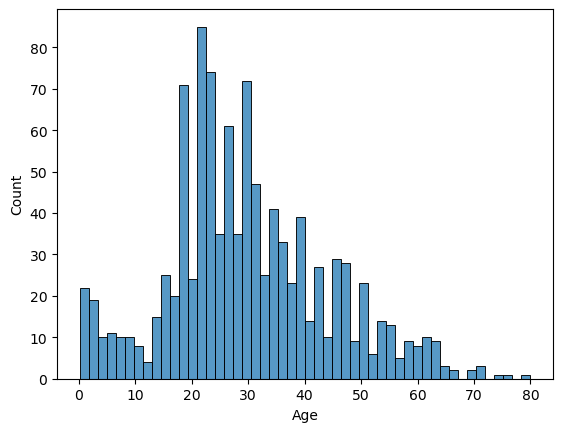

In [46]:
# Por ter muitas linhas com valores nulos vou optar por fazer a imputação simples,
# buscando correlacionar o valor da idade com outras variáveis categóricas

# A distribuição das idade está com assimetria a direita e com outliers, então vou usar mediana para imputar
sns.histplot(data=df_concat,x='Age', bins=50)

Text(0, 0.5, 'Idade')

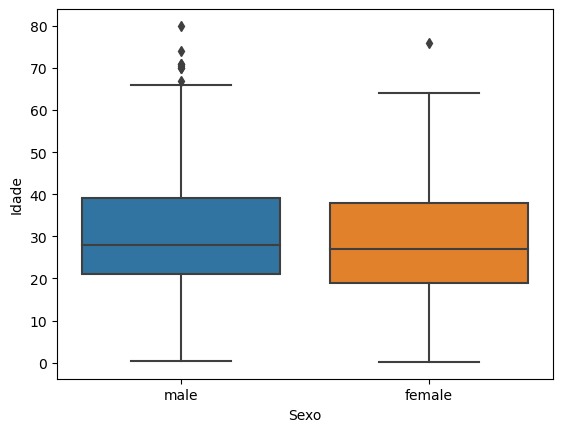

In [47]:
# Verificando distribuição das idades por sexo
sns.boxplot(data=df_concat,x='Sex', y='Age')
plt.xlabel('Sexo')
plt.ylabel('Idade')

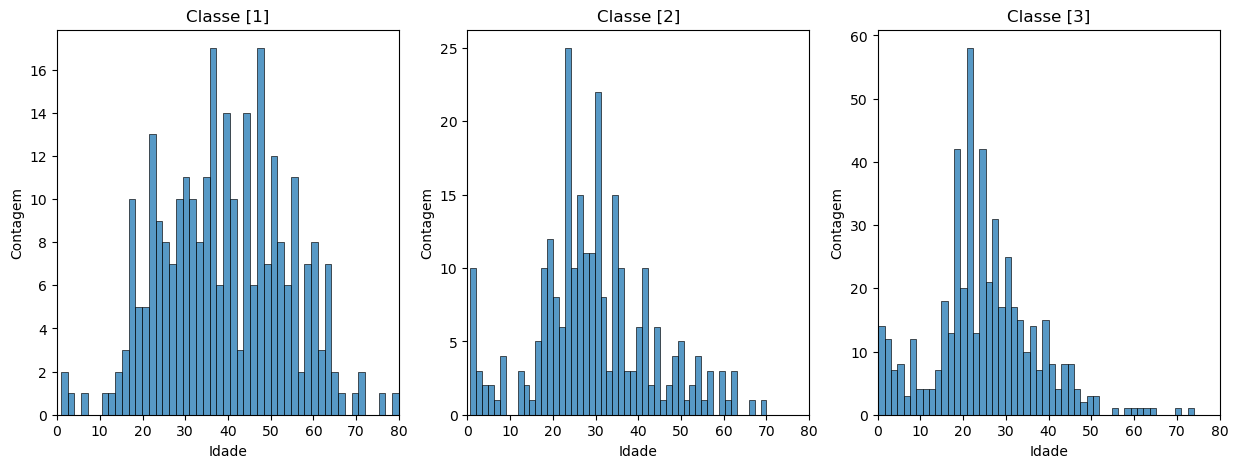

In [48]:
# A variável Pclass me ajuda a definir o melhor valor para a imputação,
# vemos que para primeira classe temos maior número de pessoas mais velhor, diferente das demais classes
classes = sorted(df_concat['Pclass'].unique())
fig, axes = plt.subplots(1, len(classes), figsize=(15,5))
for i, classe in enumerate(classes):
    sns.histplot(df_concat[df_concat['Pclass'] == classe]['Age'], bins=50, ax=axes[i])
    axes[i].set_title(f"Classe [{classe}]")
    axes[i].set_xlabel("Idade")
    axes[i].set_ylabel("Contagem")
    axes[i].set_xlim(0,80)
plt.show()

In [49]:
# Mediana da idade agrupado por classe e sexo
df_concat.groupby(['Pclass','Sex'])['Age'].median().reset_index()

,Pclass,Sex,Age
0,1,female,36.0
1,1,male,42.0
2,2,female,28.0
3,2,male,29.5
4,3,female,22.0
5,3,male,25.0


In [50]:
# Imputação com a mediana
df_concat['Age'] = df_concat['Age'].fillna(df_concat.groupby(['Pclass','Sex'])['Age'].transform('median'))

### Embarked - 2 (0,15%) linhas nulas

In [51]:
# Como são apenas dois valores nulos vou preencher com a moda
print(f"Moda: {df_concat['Embarked'].mode()[0]}")

Moda: S


In [52]:
# Imputando com a moda
df_concat['Embarked'] = df_concat['Embarked'].fillna(df_concat['Embarked'].mode()[0])

### Fare - 1 (0,07%) linha nula

In [53]:
# Calculando a mediana agrupada por classe e local da embarcação, dependendo de onde você embarca a trajeto é menor e o valor da passagem mais barata
df_concat.groupby(['Pclass','Embarked'])['Fare'].median().reset_index()

,Pclass,Embarked,Fare
0,1,C,76.7292
1,1,Q,90.0000
2,1,S,52.0000
3,2,C,15.3146
4,2,Q,12.3500
5,2,S,15.3750
6,3,C,7.8958
7,3,Q,7.7500
8,3,S,8.0500


In [54]:
# Imputando com a mediana
df_concat['Fare'] = df_concat['Fare'].fillna(df_concat.groupby(['Pclass','Embarked'])['Fare'].transform('median'))

## Engenharia de atributos

In [55]:
# Coluna para contar familiares a bordo
df_concat['FamilyCount'] = df_concat['SibSp'] + df_concat['Parch']

In [56]:
# Explorando a coluna tickets vemos que para um mesmo identiicador tem mais de uma referência
df_concat['Ticket'].value_counts().head()

Ticket
CA. 2343        11
CA 2144          8
1601             8
PC 17608         7
S.O.C. 14879     7
Name: count, dtype: int64

In [57]:
# Para validar eu agrupei por classe e local de embarque para verificar a mediana,
# para a classe 3 e Embarque C do exemplo acima, temos Fare mediano de 7.89
# Quando dividimos o Fare(69.55) pela quantidade de pessoas(11), temos 6.32,
# o que é um valor justificavel para o desconto de uma compra em conjunto
df_concat.groupby(['Pclass','Embarked'])['Fare'].median().reset_index()

,Pclass,Embarked,Fare
0,1,C,76.7292
1,1,Q,90.0000
2,1,S,52.0000
3,2,C,15.3146
4,2,Q,12.3500
5,2,S,15.3750
6,3,C,7.8958
7,3,Q,7.7500
8,3,S,8.0500


In [58]:
# Coluna para a quantidade de pessoas com o mesmo Ticket
df_concat['GroupSizeTicket'] = df_concat.groupby('Ticket')['Ticket'].transform('count')
# Calculo do valor do ticket por pessoa
df_concat['FarePerPerson'] = df_concat['Fare'] / df_concat['GroupSizeTicket']

In [59]:
df_concat.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilyCount,GroupSizeTicket,FarePerPerson
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1,1,7.25000
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,2,35.64165
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1,7.92500
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,2,26.55000
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,1,8.05000


# Análise Exploratória

In [60]:
# Olhando apenas para os dados de treinamento tratado, com a variável resposta
df_train = df_train[['PassengerId','Survived']].merge(df_concat, on='PassengerId', how='left')

In [61]:
df_train.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilyCount,GroupSizeTicket,FarePerPerson
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1,1,7.25000
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,2,35.64165
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1,7.92500
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,2,26.55000
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,1,8.05000


In [62]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   PassengerId      891 non-null    int64  
 1   Survived         891 non-null    int64  
 2   Pclass           891 non-null    int64  
 3   Name             891 non-null    object 
 4   Sex              891 non-null    object 
 5   Age              891 non-null    float64
 6   SibSp            891 non-null    int64  
 7   Parch            891 non-null    int64  
 8   Ticket           891 non-null    object 
 9   Fare             891 non-null    float64
 10  Embarked         891 non-null    object 
 11  FamilyCount      891 non-null    int64  
 12  GroupSizeTicket  891 non-null    int64  
 13  FarePerPerson    891 non-null    float64
dtypes: float64(3), int64(7), object(4)
memory usage: 97.6+ KB


Text(0.5, 1.0, 'Proporção de sobrevivência por classe')

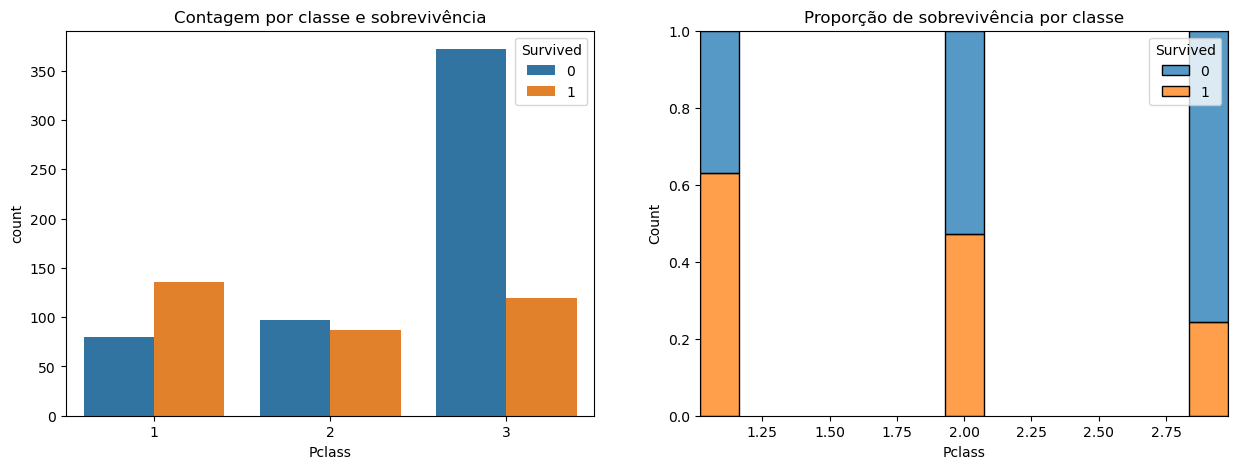

In [63]:
fig,axes = plt.subplots(1,2, figsize=(15,5))

sns.countplot(data=df_train, x='Pclass',  hue='Survived', ax=axes[0])
axes[0].set_title('Contagem por classe e sobrevivência')

sns.histplot(data=df_train, x='Pclass', multiple='fill', hue='Survived', shrink=0.8, ax=axes[1],element="bars")
axes[1].set_title('Proporção de sobrevivência por classe')

Text(0.5, 1.0, 'Proporção de sobrevivência por sexo')

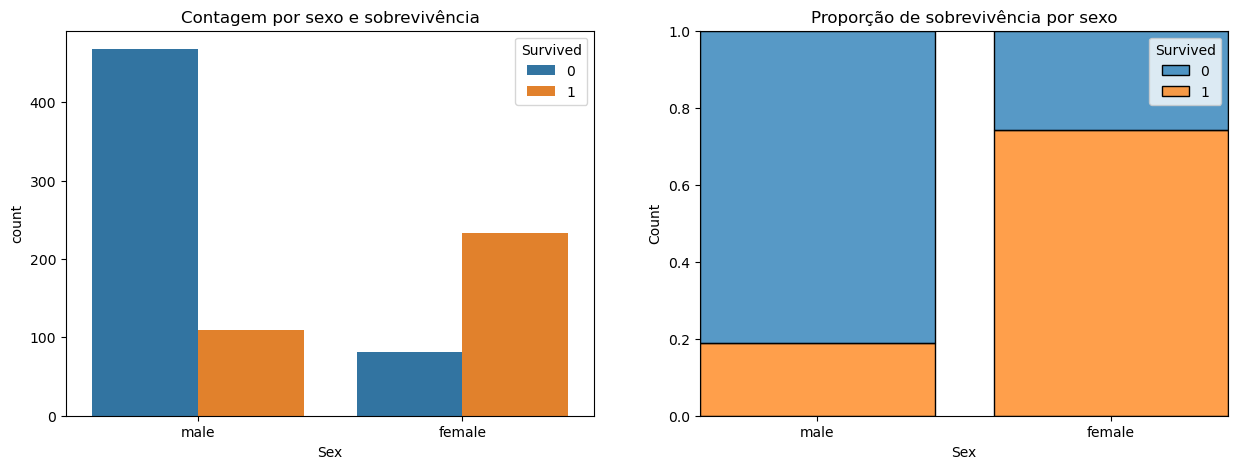

In [64]:
fig,axes = plt.subplots(1,2, figsize=(15,5))

sns.countplot(data=df_train, x='Sex',  hue='Survived', ax=axes[0])
axes[0].set_title('Contagem por sexo e sobrevivência')

sns.histplot(data=df_train, x='Sex', multiple='fill', hue='Survived', shrink=0.8, ax=axes[1],element="bars")
axes[1].set_title('Proporção de sobrevivência por sexo')

Text(0.5, 1.0, 'Proporção de sobrevivência por local do embarque')

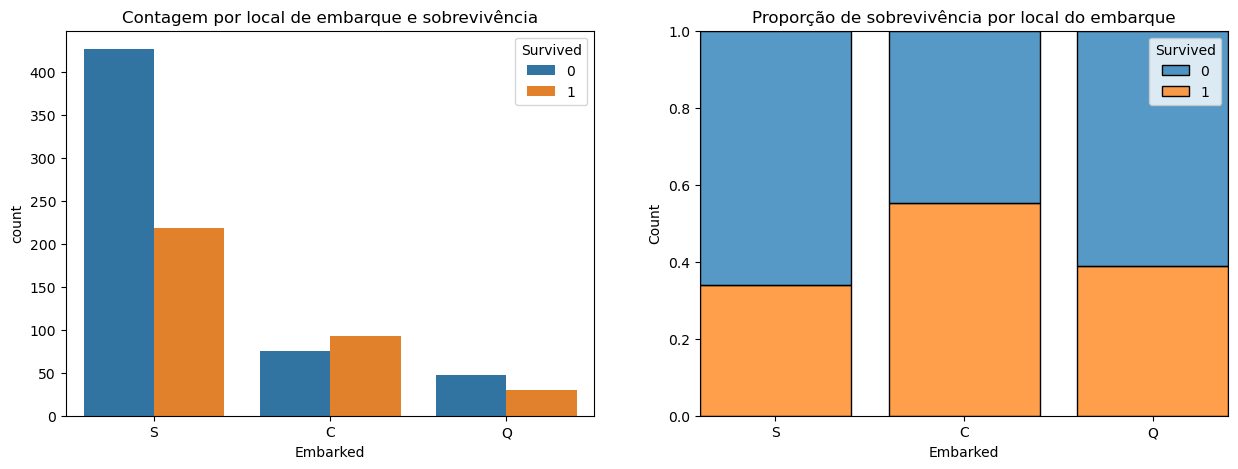

In [65]:
fig,axes = plt.subplots(1,2, figsize=(15,5))

sns.countplot(data=df_train, x='Embarked',  hue='Survived', ax=axes[0])
axes[0].set_title('Contagem por local de embarque e sobrevivência')

sns.histplot(data=df_train, x='Embarked', multiple='fill', hue='Survived', shrink=0.8, ax=axes[1],element="bars")
axes[1].set_title('Proporção de sobrevivência por local do embarque')

Text(0.5, 1.0, 'Proporção de Sobrevivência por tamanho da família a bordo')

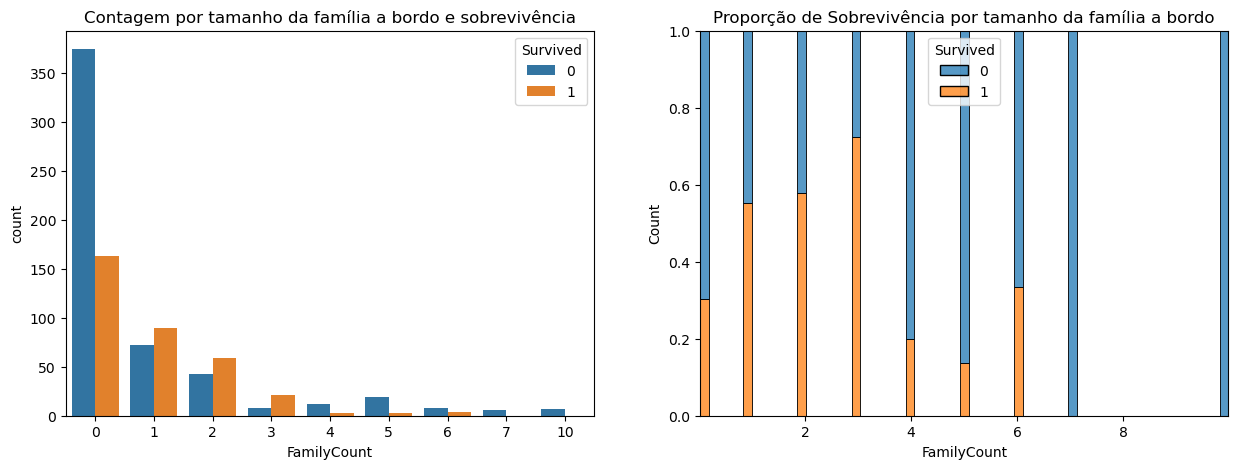

In [66]:
fig,axes = plt.subplots(1,2, figsize=(15,5))

sns.countplot(data=df_train, x='FamilyCount',  hue='Survived', ax=axes[0])
axes[0].set_title('Contagem por tamanho da família a bordo e sobrevivência')

sns.histplot(data=df_train, x='FamilyCount', multiple='fill', hue='Survived', shrink=0.8, ax=axes[1],element="bars")
axes[1].set_title('Proporção de Sobrevivência por tamanho da família a bordo')

Text(0.5, 1.0, 'Proporção de sobrevivência por número de irmãos(ãs) e/ou cônjuges abordo')

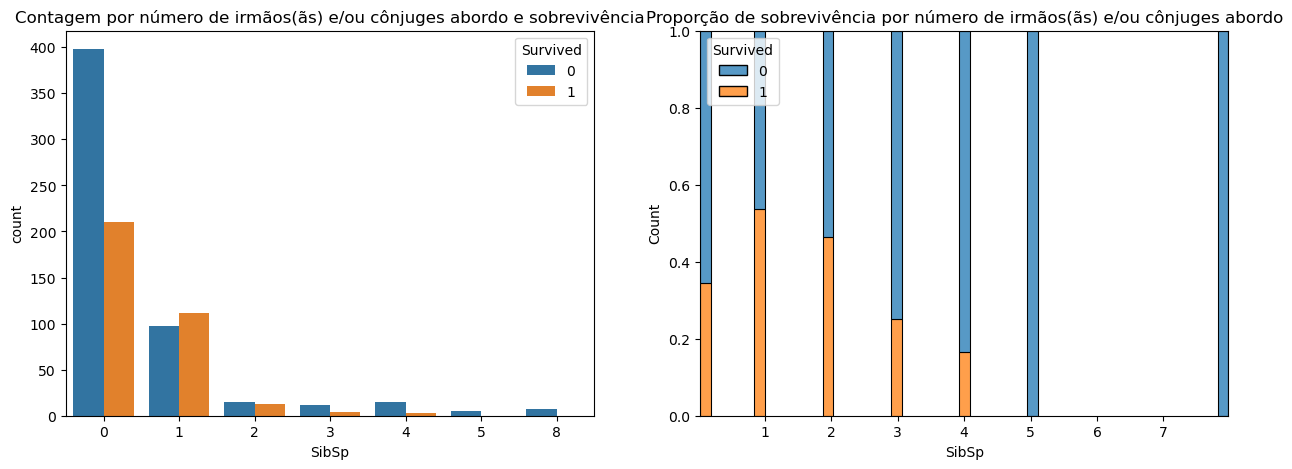

In [67]:
fig,axes = plt.subplots(1,2, figsize=(15,5))

sns.countplot(data=df_train, x='SibSp',  hue='Survived', ax=axes[0])
axes[0].set_title('Contagem por número de irmãos(ãs) e/ou cônjuges abordo e sobrevivência')

sns.histplot(data=df_train, x='SibSp', multiple='fill', hue='Survived', shrink=0.8, ax=axes[1],element="bars")
axes[1].set_title('Proporção de sobrevivência por número de irmãos(ãs) e/ou cônjuges abordo')

Text(0.5, 1.0, 'Proporção de sobrevivência por número de pais e/ou filhos a bordo')

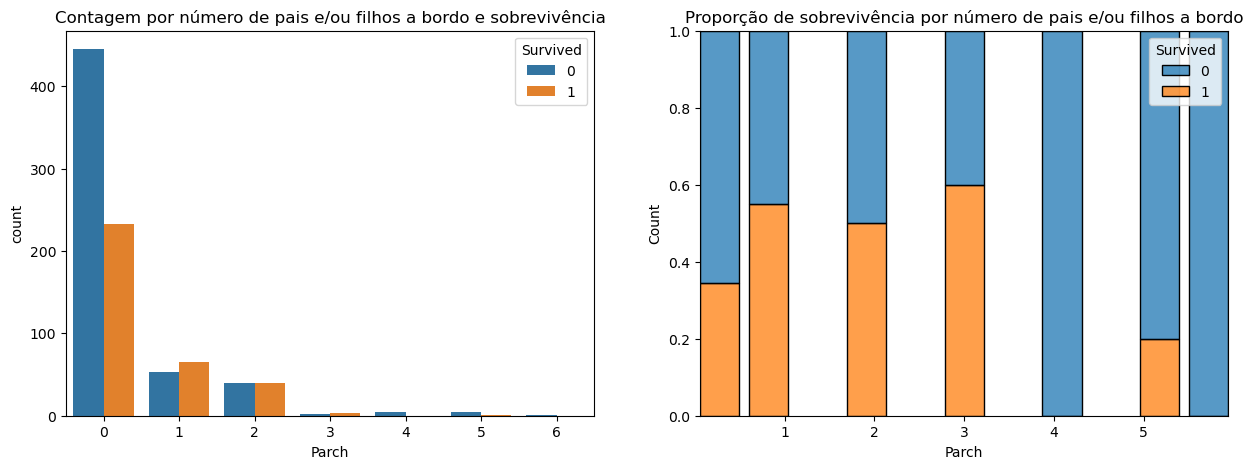

In [68]:
fig,axes = plt.subplots(1,2, figsize=(15,5))

sns.countplot(data=df_train, x='Parch',  hue='Survived', ax=axes[0])
axes[0].set_title('Contagem por número de pais e/ou filhos a bordo e sobrevivência')

sns.histplot(data=df_train, x='Parch', multiple='fill', hue='Survived', shrink=0.8, ax=axes[1],element="bars")
axes[1].set_title('Proporção de sobrevivência por número de pais e/ou filhos a bordo')

Text(0.5, 1.0, 'Proporção de sobrevivência por passagem em conjunto')

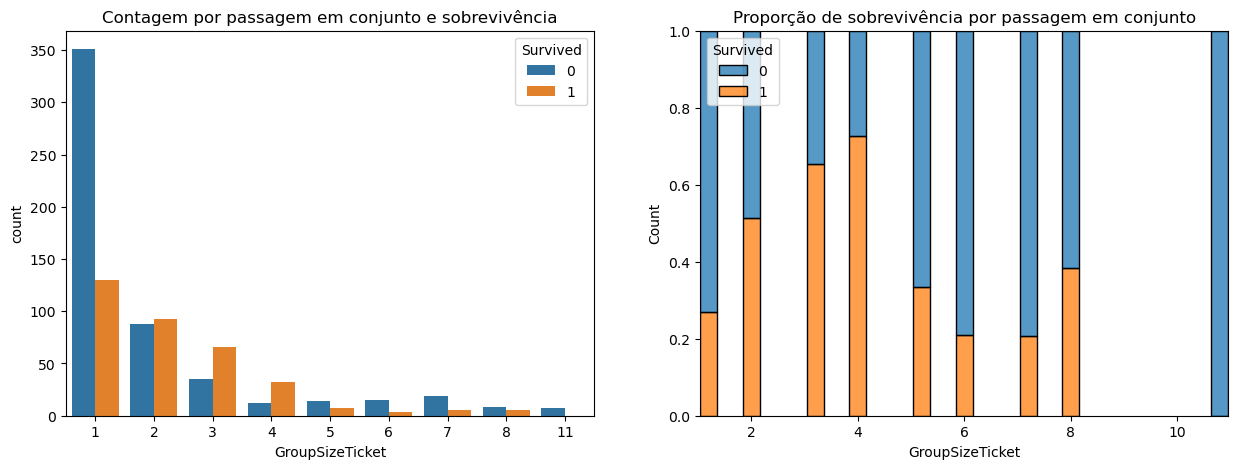

In [69]:
fig,axes = plt.subplots(1,2, figsize=(15,5))

sns.countplot(data=df_train, x='GroupSizeTicket',  hue='Survived', ax=axes[0])
axes[0].set_title('Contagem por passagem em conjunto e sobrevivência')

sns.histplot(data=df_train, x='GroupSizeTicket', multiple='fill', hue='Survived', shrink=0.8, ax=axes[1],element="bars")
axes[1].set_title('Proporção de sobrevivência por passagem em conjunto')

<Axes: xlabel='Age', ylabel='Count'>

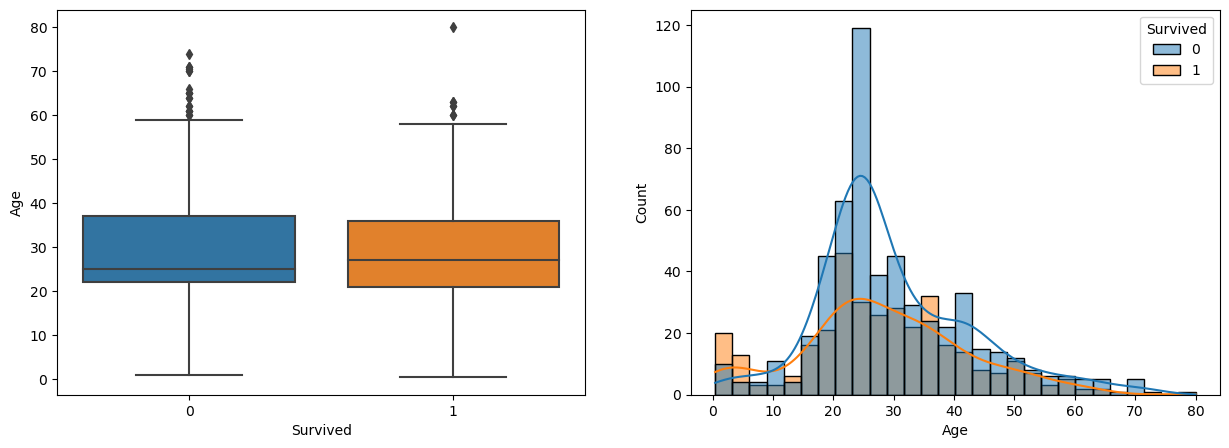

In [70]:
# Distribuição das idades por sobrevivência
fig, axes = plt.subplots(1,2, figsize=(15,5))
sns.boxplot(data=df_train, y='Age', x='Survived', ax=axes[0])
sns.histplot(data=df_train, x='Age', hue='Survived', ax=axes[1], kde=True)

<Axes: xlabel='Fare', ylabel='Count'>

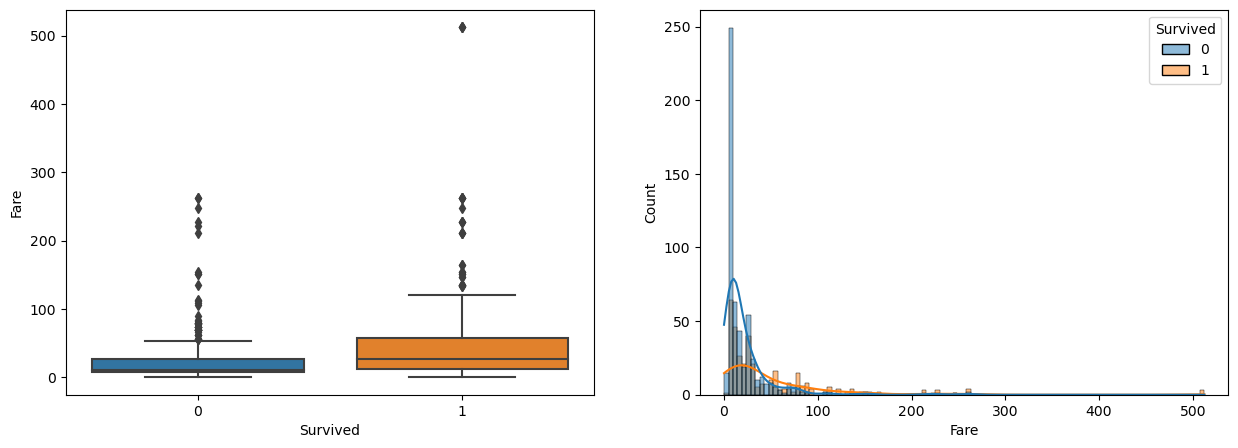

In [71]:
# Distribuição do valor da passagem
fig, axes = plt.subplots(1,2, figsize=(15,5))
sns.boxplot(data=df_train, y='Fare', x='Survived', ax=axes[0])
sns.histplot(data=df_train, x='Fare', hue='Survived', ax=axes[1], kde=True)

<Axes: xlabel='FarePerPerson', ylabel='Count'>

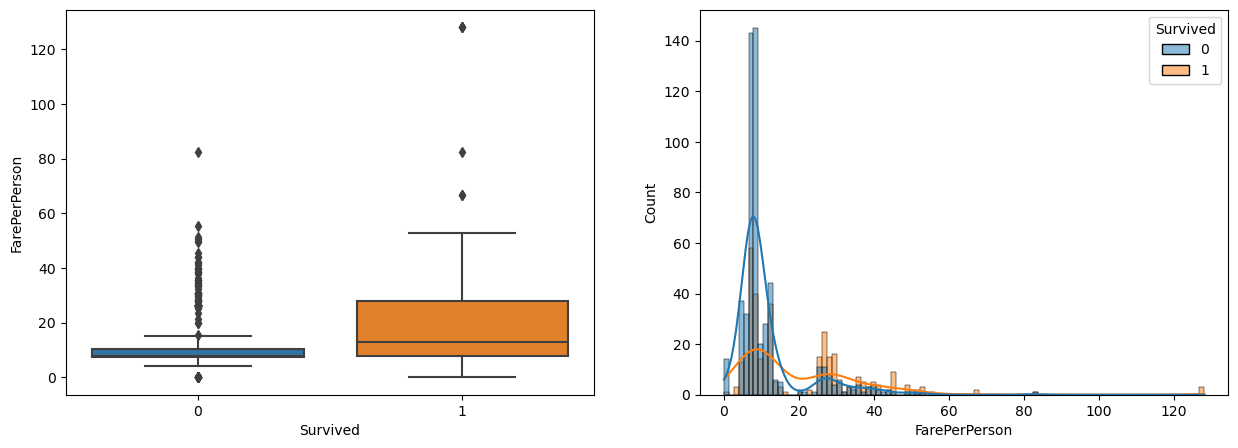

In [72]:
# Distribuição do valor da passagem por pessoa
fig, axes = plt.subplots(1,2, figsize=(15,5))
sns.boxplot(data=df_train, y='FarePerPerson', x='Survived', ax=axes[0])
sns.histplot(data=df_train, x='FarePerPerson', hue='Survived', ax=axes[1], kde=True)

## Transformação dos dados

In [73]:
df_concat.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,FamilyCount,GroupSizeTicket,FarePerPerson
0,1,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S,1,1,7.25000
1,2,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C,1,2,35.64165
2,3,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S,0,1,7.92500
3,4,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S,1,2,26.55000
4,5,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S,0,1,8.05000


In [74]:
# Padronizando variáveis numéricas
scaler = StandardScaler()
dados_numericos = scaler.fit_transform(df_concat[['Pclass','Age','SibSp','Parch','Fare','FamilyCount','GroupSizeTicket','FarePerPerson']])
df_numerico = pd.DataFrame(dados_numericos, columns=['Pclass','Age','SibSp','Parch','Fare','FamilyCount','GroupSizeTicket','FarePerPerson'])

# Tranformando variáveis categóricas
encoder = OneHotEncoder(sparse_output=False, drop='first')
dados_categoricos = encoder.fit_transform(df_concat[['Sex','Embarked']])
df_categorico = pd.DataFrame(dados_categoricos, columns=encoder.get_feature_names_out(['Sex','Embarked']))

df_final = pd.concat([df_concat[["PassengerId"]], df_numerico, df_categorico], axis=1)

In [75]:
df_final.head()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,FamilyCount,GroupSizeTicket,FarePerPerson,Sex_male,Embarked_Q,Embarked_S
0,1,0.841916,-0.549555,0.481288,-0.445,-0.503176,0.073352,-0.619174,-0.553831,1.0,0.0,1.0
1,2,-1.546098,0.661353,0.481288,-0.445,0.734809,0.073352,-0.057108,1.542028,0.0,0.0,0.0
2,3,0.841916,-0.246828,-0.479087,-0.445,-0.490126,-0.558346,-0.619174,-0.504003,0.0,0.0,1.0
3,4,-1.546098,0.434307,0.481288,-0.445,0.383263,0.073352,-0.057108,0.870886,0.0,0.0,1.0
4,5,0.841916,0.434307,-0.479087,-0.445,-0.487709,-0.558346,-0.619174,-0.494776,1.0,0.0,1.0


# Treinando o modelo

In [76]:
# Separando treino e teste
df_train = df_train[['PassengerId','Survived']].merge(df_final, how='left', on='PassengerId')
df_test = df_test[['PassengerId']].merge(df_final, how='left', on='PassengerId')

In [77]:
X_train = df_train.drop(['Survived','PassengerId'],axis=1)
y_train = df_train['Survived']
X_test = df_test.drop('PassengerId',axis=1)

In [78]:
# Treinando o modelo de regressão linear
modelo = LogisticRegression()
modelo.fit(X_train,y_train)

LogisticRegression()

In [79]:
y_pred = modelo.predict(X_test)

# Gerando arquivo para a competição

In [80]:
df_resultado = pd.DataFrame({'PassengerId': df_test["PassengerId"], "Survived": y_pred})

In [81]:
# Salvando arquivo para submissão da competição
df_resultado.to_csv('sub_20260218.csv',index=False)

# Resultado

### Precisão de 0.76076